# Step 5: Prediction Reliability Audit

Accuracy says how often the model is right. Reliability asks whether its **confidence** can be trusted (survey section 4.4).

- **Brier Score** = mean((p - y)^2). Lower is better.
- **Expected Calibration Error (ECE)** = sum over confidence bins of (bin share) x |accuracy - confidence|, where confidence = max(p, 1 - p).
- **Calibration by group**: a model can be well calibrated overall and poorly calibrated for one group.
- **Low-confidence share**: the share of predictions below 70% confidence, which is what the oversight module sends to a person.

Thresholds (ECE 0.05, Brier 0.20, group ECE gap 0.05) are documented defaults, with a sensitivity check below.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from src.model import load_processed, build_dtypes, apply_dtypes

PROCESSED_DIR = os.path.abspath("../data/processed")
RESULTS_DIR = os.path.abspath("../results")
from src.audit.reliability import audit_reliability, DEFAULT_THRESHOLDS
X_train, X_test, y_train, y_test, g_train, g_test = load_processed(PROCESSED_DIR)
dtypes = build_dtypes(X_train, X_test)
Xte = apply_dtypes(X_test, dtypes)
yte = y_test.to_numpy()

model = XGBClassifier()
model.load_model(os.path.join(RESULTS_DIR, "baseline_xgb.json"))
p = model.predict_proba(Xte)[:, 1]
print("Test rows:", Xte.shape)


Test rows: (38642, 10)


## 1. Run the audit

Calibration is checked overall and within each `RAC1P` and `SEX` group. Groups under 500 rows are skipped for calibration, because ECE over 10 bins is biased upward on small samples. Without this rule the two smallest groups (84 and 139 rows) looked badly calibrated purely from sample noise and made the whole dimension fail.

In [2]:
groups = {"RAC1P": Xte["RAC1P"].astype(float).to_numpy(), "SEX": Xte["SEX"].astype(float).to_numpy()}
result = audit_reliability(yte, p, groups)
print(result.summary())

Reliability: risk 0.326 (pass)
  - ECE 0.023, Brier score 0.130; 21.3% of predictions have confidence below 70%.


In [3]:
result.details["ece_table"].round(4)

,bin_low,bin_high,n,confidence,accuracy,gap
0,0.0,0.1,0,NaN,NaN,NaN
1,0.1,0.2,0,NaN,NaN,NaN
2,0.2,0.3,0,NaN,NaN,NaN
3,0.3,0.4,0,NaN,NaN,NaN
4,0.4,0.5,0,NaN,NaN,NaN
5,0.5,0.6,3898,0.5502,0.5449,0.0053
6,0.6,0.7,4327,0.6511,0.6231,0.0281
7,0.7,0.8,5016,0.7518,0.7343,0.0175
8,0.8,0.9,7181,0.8535,0.8151,0.0384
9,0.9,1.0,18220,0.9635,0.9418,0.0217


## 2. Reliability diagram

Points on the dashed line mean predicted probability equals the observed share eligible.

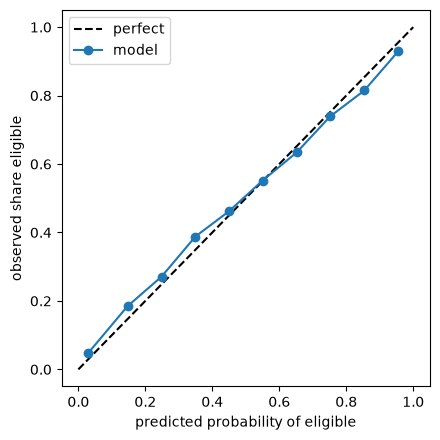

In [4]:
c = result.details["curve"]
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "k--", label="perfect")
ax.plot(c["mean_predicted"], c["observed"], "o-", label="model")
ax.set_xlabel("predicted probability of eligible")
ax.set_ylabel("observed share eligible")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
for attr, t in result.details["group_tables"].items():
    print(f"\nCalibration by {attr}")
    print(t.round(4))


Calibration by RAC1P
           n     ece   brier
group                       
9.0     6481  0.0190  0.1257
1.0    15903  0.0258  0.1317
8.0     6706  0.0193  0.1226
6.0     7189  0.0241  0.1289
2.0     1637  0.0472  0.1632
3.0      502  0.0485  0.1512

Calibration by SEX
           n     ece   brier
group                       
2.0    18272  0.0249  0.1290
1.0    20370  0.0221  0.1315


## 3. Sensitivity to the thresholds

In [6]:
rows = []
for scale in (0.5, 1.0, 1.5):
    thr = {k: v * scale for k, v in DEFAULT_THRESHOLDS.items()}
    r = audit_reliability(yte, p, groups, thresholds=thr)
    rows.append({"threshold_scale": scale, "risk": round(r.risk, 3), "status": r.status})
pd.DataFrame(rows)

,threshold_scale,risk,status
0,0.5,0.652,warn
1,1.0,0.326,pass
2,1.5,0.217,pass


In [7]:
from src.audit.common import save_result
save_result(result, os.path.join(RESULTS_DIR, "reliability_result.json"))
print("Saved")

Saved


## Summary and next step

- Measured Brier, ECE, calibration by group and the low-confidence share.
- Saved `results/reliability_result.json`.

**Next:** notebook 06, the Robustness audit.